##Libraries Setup

In [ ]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Settings for pro visuals
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.figsize": (10,6),
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
})

###1️⃣ Load Data

In [ ]:
!git clone https://github.com/Mr-Glucose/hospital-performance-bradenton-sarasota.git

fatal: destination path 'hospital-performance-bradenton-sarasota' already exists and is not an empty directory.


In [ ]:
clean = pd.read_csv("/content/hospital-performance-bradenton-sarasota/1_datasets/cleaned/hospital_clean.csv")
long  = pd.read_csv("/content/hospital-performance-bradenton-sarasota/1_datasets/cleaned/hospital_measures_long.csv")

clean.head(2), long.head(2)

(   Provider ID               Hospital Name       City State  ZIP Code  \
 0       100035   MANATEE MEMORIAL HOSPITAL  BRADENTON    FL     34208   
 1       100087  SARASOTA MEMORIAL HOSPITAL   SARASOTA    FL     34239   
 
    Readmission_Score_mean  Readmission_Score_median  Readmission_n  \
 0                  0.9975                   0.98685              6   
 1                  0.9202                   0.94225              6   
 
    HCAHPS_LinearMean_mean  HCAHPS_Star_mean  HCAHPS_ResponseRate_mean  \
 0                    79.8          1.818182                      18.0   
 1                    84.2          2.909091                      28.0   
 
    HCAHPS_n  Safety_Score_mean  Safety_n  
 0        93            12.8200        20  
 1        93             9.6685        20  ,
    Provider ID                 Measure   Score        Domain  \
 0       100035        READM-30-PN-HRRP  0.9923  Readmissions   
 1       100035  READM-30-HIP-KNEE-HRRP  0.9761  Readmissions   
 
       

In [ ]:
clean[['Hospital Name',
       'Readmission_Score_mean',
       'HCAHPS_LinearMean_mean',
       'Safety_Score_mean']]


,Hospital Name,Readmission_Score_mean,HCAHPS_LinearMean_mean,Safety_Score_mean
0,MANATEE MEMORIAL HOSPITAL,0.99750,79.8,12.820000
1,SARASOTA MEMORIAL HOSPITAL,0.92020,84.2,9.668500
2,HCA FLORIDA BLAKE HOSPITAL,0.99780,77.2,13.067500
3,LAKEWOOD RANCH MEDICAL CENTER,0.95404,83.0,12.964211


###2️⃣ Overview Tables

In [ ]:
display(clean.describe(include='all'))
display(clean[['Readmission_Score_mean','HCAHPS_LinearMean_mean','Safety_Score_mean']].corr())

,Provider ID,Hospital Name,City,State,ZIP Code,Readmission_Score_mean,Readmission_Score_median,Readmission_n,HCAHPS_LinearMean_mean,HCAHPS_Star_mean,HCAHPS_ResponseRate_mean,HCAHPS_n,Safety_Score_mean,Safety_n
count,4.000000,4,4,4,4.000000,4.000000,4.000000,4.0,4.00000,4.000000,4.000000,4.0,4.000000,4.0
unique,NaN,4,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,MANATEE MEMORIAL HOSPITAL,BRADENTON,FL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,100158.500000,NaN,NaN,NaN,34214.500000,0.967385,0.969250,6.0,81.05000,2.159091,23.500000,93.0,12.130053,20.0
std,119.826263,NaN,NaN,NaN,16.623277,0.037579,0.035034,0.0,3.16807,0.697793,4.434712,0.0,1.644171,0.0
min,100035.000000,NaN,NaN,NaN,34202.000000,0.920200,0.937900,6.0,77.20000,1.363636,18.000000,93.0,9.668500,20.0
25%,100074.000000,NaN,NaN,NaN,34206.500000,0.945580,0.941163,6.0,79.15000,1.704545,21.000000,93.0,12.032125,20.0
50%,100150.000000,NaN,NaN,NaN,34208.500000,0.975770,0.964550,6.0,81.40000,2.181818,24.000000,93.0,12.892105,20.0
75%,100234.500000,NaN,NaN,NaN,34216.500000,0.997575,0.992638,6.0,83.30000,2.636364,26.500000,93.0,12.990033,20.0


,Readmission_Score_mean,HCAHPS_LinearMean_mean,Safety_Score_mean
Readmission_Score_mean,1.000000,-0.922276,0.832480
HCAHPS_LinearMean_mean,-0.922276,1.000000,-0.678262
Safety_Score_mean,0.832480,-0.678262,1.000000


##3️⃣ Core Visuals

###🟦 A. Bar — Readmission Scores

/tmp/ipython-input-908388336.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




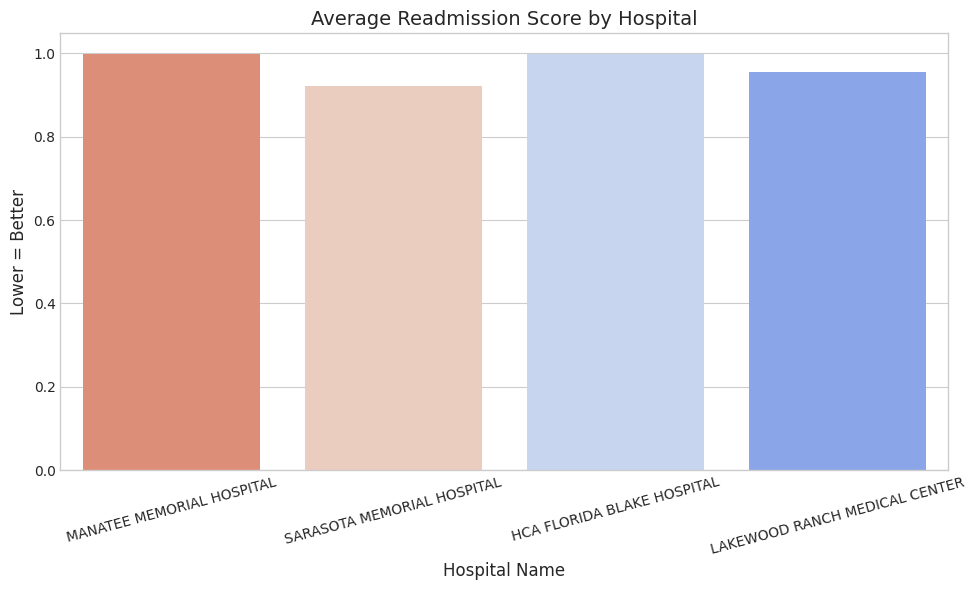

In [ ]:
sns.barplot(data=clean, x='Hospital Name', y='Readmission_Score_mean', palette='coolwarm_r')
plt.title('Average Readmission Score by Hospital')
plt.ylabel('Lower = Better')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

###💛 B. Bar — HCAHPS (Linear Mean)

/tmp/ipython-input-622027642.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




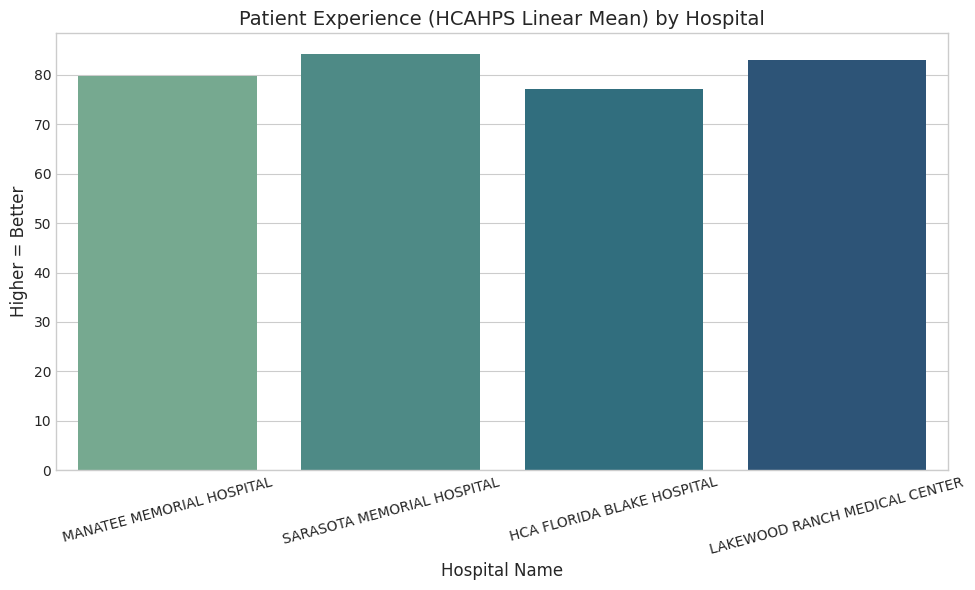

In [ ]:
sns.barplot(data=clean, x='Hospital Name', y='HCAHPS_LinearMean_mean', palette='crest')
plt.title('Patient Experience (HCAHPS Linear Mean) by Hospital')
plt.ylabel('Higher = Better')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### C. Bar — Safety Score

/tmp/ipython-input-4242497106.py:1: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




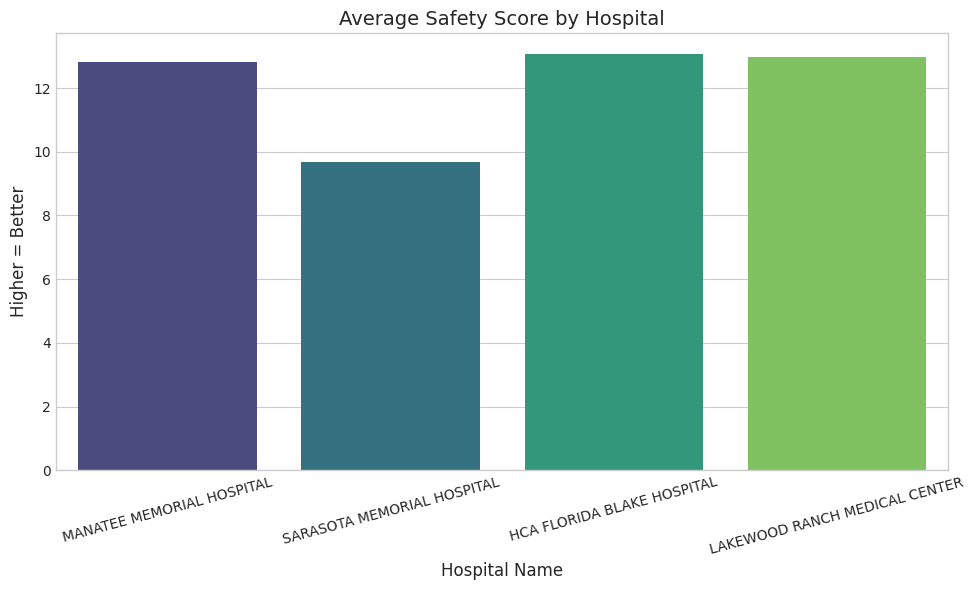

In [ ]:
sns.barplot(data=clean, x='Hospital Name', y='Safety_Score_mean', palette='viridis')
plt.title('Average Safety Score by Hospital')
plt.ylabel('Higher = Better')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

###D. Correlation Heatmap

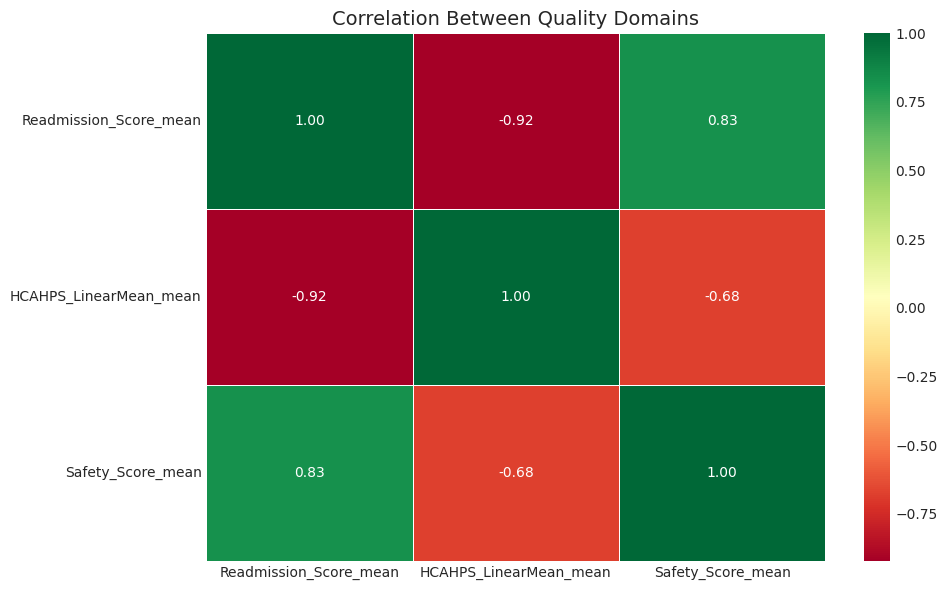

In [ ]:
corr = clean[['Readmission_Score_mean','HCAHPS_LinearMean_mean','Safety_Score_mean']].corr()
sns.heatmap(corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Quality Domains')
plt.tight_layout()
plt.show()

###E. Interactive Dashboard (Plotly Express)

In [ ]:
fig = px.bar(clean.melt(id_vars=['Hospital Name'],
                        value_vars=['Readmission_Score_mean','HCAHPS_LinearMean_mean','Safety_Score_mean'],
                        var_name='Domain', value_name='Score'),
             x='Hospital Name', y='Score', color='Domain',
             title='Hospital Performance Comparison',
             barmode='group', color_discrete_sequence=px.colors.qualitative.Safe)
fig.update_layout(title_x=0.5, template='plotly_white')
fig.show()

####POLISHED DASHBOARD VISUALS (PORTFOLIO-READY)

In [ ]:
import plotly.graph_objects as go

# Consistent color palette by hospital
hospital_colors = {
    "MANATEE MEMORIAL HOSPITAL": "#1f77b4",
    "SARASOTA MEMORIAL HOSPITAL": "#ff7f0e",
    "HCA FLORIDA BLAKE HOSPITAL": "#2ca02c",
    "LAKEWOOD RANCH MEDICAL CENTER": "#9467bd",
}

# Melt for grouped bars
melted = clean.melt(
    id_vars=["Hospital Name"],
    value_vars=[
        "Readmission_Score_mean",
        "HCAHPS_LinearMean_mean",
        "Safety_Score_mean",
    ],
    var_name="Domain",
    value_name="Score",
)

fig = px.bar(
    melted,
    x="Hospital Name",
    y="Score",
    color="Domain",
    barmode="group",
    text_auto=".2f",
    color_discrete_sequence=px.colors.qualitative.Safe,
    title="🏥 Hospital Quality Comparison — Readmission vs HCAHPS vs Safety",
)

fig.update_layout(
    title_x=0.5,
    xaxis_title=None,
    yaxis_title="Score",
    legend_title_text="Domain",
    font=dict(family="Arial", size=13),
    template="plotly_white",
    bargap=0.25,
    height=500,
)
fig.update_traces(textfont_size=12)
fig.show()

#####Storytelling (radar chart)

In [ ]:
categories = ["Readmission_Score_mean","HCAHPS_LinearMean_mean","Safety_Score_mean"]
categories_clean = ["Readmission","HCAHPS","Safety"]

fig = go.Figure()

for _, row in clean.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row[c] for c in categories],
        theta=categories_clean,
        fill='toself',
        name=row["Hospital Name"],
        line=dict(width=2),
    ))

fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, max(clean["HCAHPS_LinearMean_mean"]) + 5])),
    showlegend=True,
    title="🏆 Balanced Performance Radar Chart Across Quality Domains",
    title_x=0.5,
    template="plotly_white",
)
fig.show()

##4️⃣ HCAHPS Deep Dive — Top & Bottom Questions

# Task
Analyze the patient-experience data (HCAHPS) to identify the highest and lowest scoring questions overall and per hospital, visualize the results with charts, and provide a summary of each hospital's strengths and opportunities.

## Analyze overall top and bottom hcahps questions

### Subtask:
Calculate the average scores for each HCAHPS measure across all hospitals and identify the top 5 and bottom 5 measures.


**Reasoning**:
Filter the `long` dataframe to include only HCAHPS data, calculate the mean score for each pretty measure, and then find the top and bottom 5 measures.



In [ ]:
hcahps_long = long[long["Domain"] == "HCAHPS"].copy()

hcahps_global = (
    hcahps_long.groupby("Measure_pretty", as_index=True)["Score"].mean().to_frame()
)

hcahps_bottom = hcahps_global.sort_values("Score", ascending=True).head(5)
hcahps_top = hcahps_global.sort_values("Score", ascending=False).head(5)

display(hcahps_top)
display(hcahps_bottom)

,Score
Measure_pretty,
Nurse communication (Linear score),88.50
Doctor communication (Linear score),86.50
Clean Linear Score,84.25
Hospital rating (Linear score),84.00
Discharge information (Linear score),83.75


,Score
Measure_pretty,
Communication about medicines (Linear score),69.75
Quiet Linear Score,73.50
Care transition (Linear score),77.75
Staff responsiveness (Linear score),79.00
Would recommend this hospital (Linear score),83.50


## Visualize overall top and bottom hcahps questions

### Subtask:
Create bar charts to visualize the average scores for the top 5 and bottom 5 HCAHPS measures.


**Reasoning**:
Create horizontal bar charts to visualize the top 5 and bottom 5 HCAHPS measures based on their average scores.



In [ ]:
fig_top = px.bar(hcahps_top, x="Score", y=hcahps_top.index, orientation="h",
                 title="Top 5 HCAHPS Measures (Avg)",
                 text=hcahps_top["Score"].round(1))
fig_top.update_traces(textposition="outside")
fig_top.update_layout(yaxis_title="", xaxis_title="Score")

fig_bot = px.bar(hcahps_bottom, x="Score", y=hcahps_bottom.index, orientation="h",
                 title="Bottom 5 HCAHPS Measures (Avg)",
                 text=hcahps_bottom["Score"].round(1), color="Score",
                 color_continuous_scale="Reds")
fig_bot.update_traces(textposition="outside")
fig_bot.update_layout(yaxis_title="", xaxis_title="Score")

fig_top.show()
fig_bot.show()

## Analyze top and bottom hcahps questions per hospital

### Subtask:
For each hospital, calculate the average scores for each HCAHPS measure and identify the top 5 and bottom 5 measures.


**Reasoning**:
Filter the long dataframe to include only HCAHPS data, then group by hospital and measure to calculate the mean score for each measure per hospital. After that, identify the top 5 and bottom 5 measures for each hospital and combine the results into a single dataframe with a 'Tier' column.



In [ ]:
hcahps = long[long["Domain"] == "HCAHPS"].copy()

hcahps_by_hospital = (
    hcahps.groupby(["Hospital Name", "Measure_pretty"])["Score"].mean().reset_index()
)

top_bottom_measures = []

for hospital in hcahps_by_hospital["Hospital Name"].unique():
    hospital_data = hcahps_by_hospital[
        hcahps_by_hospital["Hospital Name"] == hospital
    ].dropna(subset=["Score"])

    top5 = hospital_data.nlargest(5, "Score").copy()
    top5["Tier"] = "Top 5"
    bottom5 = hospital_data.nsmallest(5, "Score").copy()
    bottom5["Tier"] = "Bottom 5"

    top_bottom_measures.extend([top5, bottom5])

top_bottom_df = pd.concat(top_bottom_measures)

display(top_bottom_df)

,Hospital Name,Measure_pretty,Score,Tier
68,HCA FLORIDA BLAKE HOSPITAL,Nurse communication (Linear score),85.0,Top 5
44,HCA FLORIDA BLAKE HOSPITAL,Doctor communication (Linear score),84.0,Top 5
11,HCA FLORIDA BLAKE HOSPITAL,Clean Linear Score,82.0,Top 5
31,HCA FLORIDA BLAKE HOSPITAL,Discharge information (Linear score),80.0,Top 5
51,HCA FLORIDA BLAKE HOSPITAL,Hospital rating (Linear score),79.0,Top 5
12,HCA FLORIDA BLAKE HOSPITAL,Communication about medicines (Linear score),66.0,Bottom 5
76,HCA FLORIDA BLAKE HOSPITAL,Quiet Linear Score,68.0,Bottom 5
6,HCA FLORIDA BLAKE HOSPITAL,Care transition (Linear score),75.0,Bottom 5
83,HCA FLORIDA BLAKE HOSPITAL,Staff responsiveness (Linear score),75.0,Bottom 5
91,HCA FLORIDA BLAKE HOSPITAL,Would recommend this hospital (Linear score),78.0,Bottom 5


## Visualize top hcahps questions per hospital

### Subtask:
Create a treemap to visualize the top HCAHPS questions for each hospital.


**Reasoning**:
Filter the DataFrame to include only the top 5 measures and create a treemap to visualize the top HCAHPS questions for each hospital using Plotly Express.



In [ ]:
top_measures_df = top_bottom_df[top_bottom_df['Tier'] == 'Top 5'].copy()

fig = px.treemap(top_measures_df,
                 path=['Hospital Name', 'Measure_pretty'],
                 values='Score',
                 color='Measure_pretty',
                 title='Top 5 HCAHPS Measures by Hospital')
fig.show()

## Summarize hospital performance

### Subtask:
Based on the analysis, create a summary of the strengths and opportunities for each hospital based on their top and bottom HCAHPS scores.


**Reasoning**:
Filter the DataFrame to get the bottom 5 HCAHPS measures for each hospital and then iterate through each hospital to print a summary of their strengths and opportunities based on the top and bottom measures.



In [ ]:
bottom_measures_df = top_bottom_df[top_bottom_df['Tier'] == 'Bottom 5'].copy()

for hospital in top_bottom_df['Hospital Name'].unique():
    print(f"--- {hospital} ---")

    hospital_top = top_bottom_df[(top_bottom_df['Hospital Name'] == hospital) & (top_bottom_df['Tier'] == 'Top 5')]
    print("\nStrengths (Top 5 HCAHPS Measures):")
    if not hospital_top.empty:
        for index, row in hospital_top.iterrows():
            print(f"- {row['Measure_pretty']}: {row['Score']:.2f}")
    else:
        print("No top 5 measures found.")

    hospital_bottom = top_bottom_df[(top_bottom_df['Hospital Name'] == hospital) & (top_bottom_df['Tier'] == 'Bottom 5')]
    print("\nOpportunities (Bottom 5 HCAHPS Measures):")
    if not hospital_bottom.empty:
        for index, row in hospital_bottom.iterrows():
            print(f"- {row['Measure_pretty']}: {row['Score']:.2f}")
    else:
        print("No bottom 5 measures found.")
    print("-" * 20)

--- HCA FLORIDA BLAKE HOSPITAL ---

Strengths (Top 5 HCAHPS Measures):
- Nurse communication (Linear score): 85.00
- Doctor communication (Linear score): 84.00
- Clean Linear Score: 82.00
- Discharge information (Linear score): 80.00
- Hospital rating (Linear score): 79.00

Opportunities (Bottom 5 HCAHPS Measures):
- Communication about medicines (Linear score): 66.00
- Quiet Linear Score: 68.00
- Care transition (Linear score): 75.00
- Staff responsiveness (Linear score): 75.00
- Would recommend this hospital (Linear score): 78.00
--------------------
--- LAKEWOOD RANCH MEDICAL CENTER ---

Strengths (Top 5 HCAHPS Measures):
- Nurse communication (Linear score): 90.00
- Clean Linear Score: 87.00
- Doctor communication (Linear score): 87.00
- Discharge information (Linear score): 86.00
- Hospital rating (Linear score): 85.00

Opportunities (Bottom 5 HCAHPS Measures):
- Communication about medicines (Linear score): 73.00
- Quiet Linear Score: 77.00
- Care transition (Linear score): 79.00

## Summary:

### Data Analysis Key Findings

*   Globally, the top 5 HCAHPS measures by average score are: Nurse communication (88.50), Doctor communication (86.50), Clean Linear Score (84.25), Hospital rating (84.00), and Discharge information (83.75).
*   Globally, the bottom 5 HCAHPS measures by average score are: Communication about medicines (69.75), Quiet Linear Score (73.50), Care transition (77.75), Staff responsiveness (79.00), and Would recommend this hospital (83.50).
*   The analysis identified the top 5 and bottom 5 HCAHPS measures for each individual hospital based on their average scores.
*   Visualizations were created to show the top and bottom HCAHPS measures overall and a treemap showed the top measures per hospital.
*   Summaries of strengths (top 5 measures) and opportunities (bottom 5 measures) were generated for each hospital, including the specific measure and its average score.

### Insights or Next Steps

*   Hospitals should focus on improving performance in the bottom-scoring areas, particularly "Communication about medicines" and "Quiet Linear Score," as these are consistently low across all hospitals.
*   Individual hospitals can leverage their strengths (top 5 measures) in communication and cleanliness while developing targeted strategies to address opportunities in areas like noise reduction and medication communication to enhance overall patient experience.


In [57]:
!pip install -q kaleido


## Save charts as images

### Subtask:
Save the generated Plotly figures as image files (PNG).

In [68]:
!pip install -q kaleido

**Reasoning**:
List the files in the output directory again to confirm its contents and the path.

In [71]:
import os

out_dir = "/content/hospital-performance-bradenton-sarasota/4_outputs"

if os.path.exists(out_dir):
  print(f"Contents of {out_dir}:")
  for filename in os.listdir(out_dir):
    print(filename)
else:
  print(f"Directory not found: {out_dir}")

Contents of /content/hospital-performance-bradenton-sarasota/4_outputs:


In [62]:
%%bash
cd /content/hospital-performance-bradenton-sarasota

# set identity only for THIS repo (no --global)
git config user.name  "Arthur Dorvil"
git config user.email "Dorvillensmarcarthur@gmail.com"

git config --list --local | grep user.

user.name=Arthur Dorvil
user.email=Dorvillensmarcarthur@gmail.com


## Save charts as images

### Subtask:
Save the generated Plotly figures as image files (PNG).

**Reasoning**:
Import necessary libraries, define the output directory, create the directory if it doesn't exist, and use `plotly.io.write_image` to save each figure.

In [74]:
import plotly.io as pio
import os

out_dir = "/content/hospital-performance-bradenton-sarasota/4_outputs"
os.makedirs(out_dir, exist_ok=True)

# Assuming fig_top, fig_bot, and fig are your Plotly figures
# If you named your treemap figure differently, please adjust 'fig' accordingly
try:
    pio.write_image(fig_top,   f"{out_dir}/fig_top5_hcahps.png", scale=2)
    pio.write_image(fig_bot,   f"{out_dir}/fig_bottom5_hcahps.png", scale=2)
    pio.write_image(fig,  f"{out_dir}/fig_treemap_hcahps.png", scale=2) # Assuming treemap figure is named 'fig'

    print("✅ Charts saved to:", out_dir)
except NameError:
    print("Error: One or more figures (fig_top, fig_bot, or fig) are not defined.")
    print("Please ensure you have run the cells that generate these figures before saving.")
except Exception as e:
    print(f"An error occurred while saving the images: {e}")

An error occurred while saving the images: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido



In [63]:
!cd /content/hospital-performance-bradenton-sarasota && \
  git add 4_outputs/*.png && \
  git commit -m "Day 5: HCAHPS visualizations (Top 5, Bottom 5, Treemap)" || echo "No new changes to commit"

fatal: pathspec '4_outputs/*.png' did not match any files
No new changes to commit
